In [1]:
# =============================================================================
# SETUP — Install & Imports
# =============================================================================
import sys
!{sys.executable} -m pip install econml --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from econml.dml import LinearDML, CausalForestDML

print("All imports successful")


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


All imports successful


In [2]:
# =============================================================================
# DATA LOADING & FEATURE PREPARATION
# =============================================================================
DATA_PATH = r"C:\Users\sudhi\Music\full_dataset_profit_clv.csv"
ci_df = pd.read_csv(DATA_PATH)

# Encode Customer_State
ci_df['State_Numeric'] = (ci_df['Customer_State'] == 'Active').astype(int)

# One row per customer — latest year
ci_clean = (ci_df.sort_values('Year', ascending=False)
                 .drop_duplicates(subset='Customer ID', keep='first')
                 .reset_index(drop=True))

# Variable definitions
outcome_col     = 'ProfitCLV'
confounder_cols = ['Frequency', 'Monetary_Value', 'FirstPurchaseRevenue']
treatment_cols  = ['Predicted_Purchases', 'Predicted_Monetary_Value',
                   'State_Numeric', 'Cluster_Label']
treatment_short = ['BG-NBD Pred. Purchases', 'Gamma-Gamma Pred. Monetary',
                   'Markov Customer State',   'K-Means Cluster Label']
treatment_labels= ['BG-NBD\nPred. Purchases', 'Gamma-Gamma\nPred. Monetary',
                   'Markov\nCustomer State',   'K-Means\nCluster Label']

# Build clean arrays
all_cols = confounder_cols + treatment_cols + [outcome_col]
df_model = ci_clean[all_cols].copy()
imp = SimpleImputer(strategy='mean')
df_model_imp = pd.DataFrame(imp.fit_transform(df_model), columns=all_cols)

# Add Market_Group back
df_model_imp['Market_Group'] = ci_clean['Market_Group'].values

Y = df_model_imp[outcome_col].values
W = df_model_imp[confounder_cols].values

print(f"Customers: {len(ci_clean)}")
print(f"ProfitCLV — mean: {Y.mean():.2f}, std: {Y.std():.2f}")

# ==========================================================================
# WHY THIS STEP?
# We take one row per customer (latest year) to avoid pseudo-replication.
# Confounders W capture historical LRFM behaviour that drives BOTH the
# engineered features AND ProfitCLV — the core confounding structure.
# SimpleImputer with mean fills the few missing values so models don't crash.
# ==========================================================================

Customers: 3580
ProfitCLV — mean: 835.44, std: 4050.58


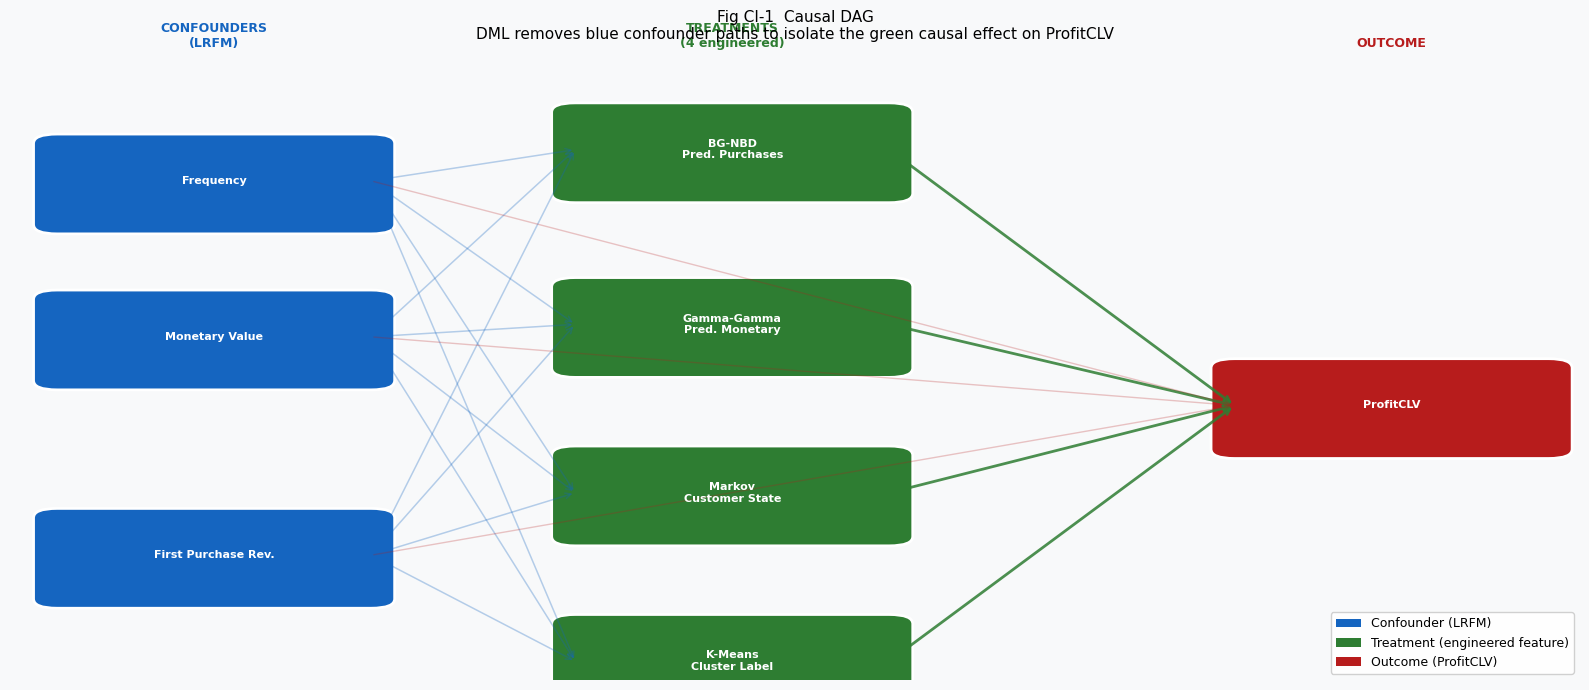

In [11]:
# =============================================================================
# CELL 1 — Causal DAG
# =============================================================================
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(16, 7))
ax.set_facecolor('#f8f9fa'); fig.patch.set_facecolor('#f8f9fa')

pos = {
    'Frequency'           : (0.13, 0.80),
    'Monetary Value'      : (0.13, 0.55),
    'First Purchase Rev.' : (0.13, 0.20),
    'BG-NBD\nPred. Purchases'     : (0.46, 0.85),
    'Gamma-Gamma\nPred. Monetary' : (0.46, 0.57),
    'Markov\nCustomer State'      : (0.46, 0.30),
    'K-Means\nCluster Label'      : (0.46, 0.03),
    'ProfitCLV'                   : (0.88, 0.44),
}
node_colors = {
    'Frequency':'#1565C0','Monetary Value':'#1565C0','First Purchase Rev.':'#1565C0',
    'BG-NBD\nPred. Purchases':'#2E7D32','Gamma-Gamma\nPred. Monetary':'#2E7D32',
    'Markov\nCustomer State':'#2E7D32','K-Means\nCluster Label':'#2E7D32',
    'ProfitCLV':'#B71C1C',
}
for node,(x,y) in pos.items():
    ax.add_patch(FancyBboxPatch((x-0.10,y-0.07),0.20,0.13,boxstyle="round,pad=0.015",
        facecolor=node_colors[node],edgecolor='white',linewidth=2,transform=ax.transAxes,zorder=3))
    ax.text(x,y,node,ha='center',va='center',fontsize=8,color='white',
            fontweight='bold',transform=ax.transAxes,zorder=4)

confs  = ['Frequency','Monetary Value','First Purchase Rev.']
treats = ['BG-NBD\nPred. Purchases','Gamma-Gamma\nPred. Monetary',
          'Markov\nCustomer State','K-Means\nCluster Label']

def arr(src,dst,col,lw,alpha):
    x1,y1=pos[src]; x2,y2=pos[dst]
    ax.annotate('',xy=(x2-0.10,y2),xytext=(x1+0.10,y1),xycoords='axes fraction',
                textcoords='axes fraction',
                arrowprops=dict(arrowstyle='->',color=col,lw=lw,alpha=alpha))

for c in confs:
    for t in treats: arr(c,t,'#1565C0',1.1,0.3)
for t in treats:     arr(t,'ProfitCLV','#2E7D32',2.0,0.85)
for c in confs:      arr(c,'ProfitCLV','#B71C1C',1.0,0.25)

for x,lbl,col in [(0.13,'CONFOUNDERS\n(LRFM)','#1565C0'),
                  (0.46,'TREATMENTS\n(4 engineered)','#2E7D32'),
                  (0.88,'OUTCOME','#B71C1C')]:
    ax.text(x,1.01,lbl,ha='center',va='bottom',fontsize=9,fontweight='bold',
            color=col,transform=ax.transAxes)

ax.legend(handles=[
    mpatches.Patch(facecolor='#1565C0',label='Confounder (LRFM)'),
    mpatches.Patch(facecolor='#2E7D32',label='Treatment (engineered feature)'),
    mpatches.Patch(facecolor='#B71C1C',label='Outcome (ProfitCLV)'),
],loc='lower right',fontsize=9,framealpha=0.9)
ax.set_xlim(-0.05,1.05); ax.set_ylim(-0.05,1.12); ax.axis('off')
ax.set_title('Fig CI-1  Causal DAG\nDML removes blue confounder paths to isolate the green causal effect on ProfitCLV',
             fontsize=11,pad=12)
plt.tight_layout(); plt.show()

# ==========================================================================
# HOW TO READ THIS DAG:
# Blue arrows  = LRFM confounders affect both the 4 treatment features AND ProfitCLV.
#                If we don't remove this, raw correlation mixes causal + confounded signal.
# Green arrows = The CAUSAL paths we want to estimate (treatment -> ProfitCLV).
# Red arrows   = Direct LRFM -> ProfitCLV paths (also confounded, handled by DML).
# DML partials out the blue arrows via RF residualisation (see Cell 3).
# No colliders present — we control only for confounders (W), NOT for downstream effects.
# ==========================================================================

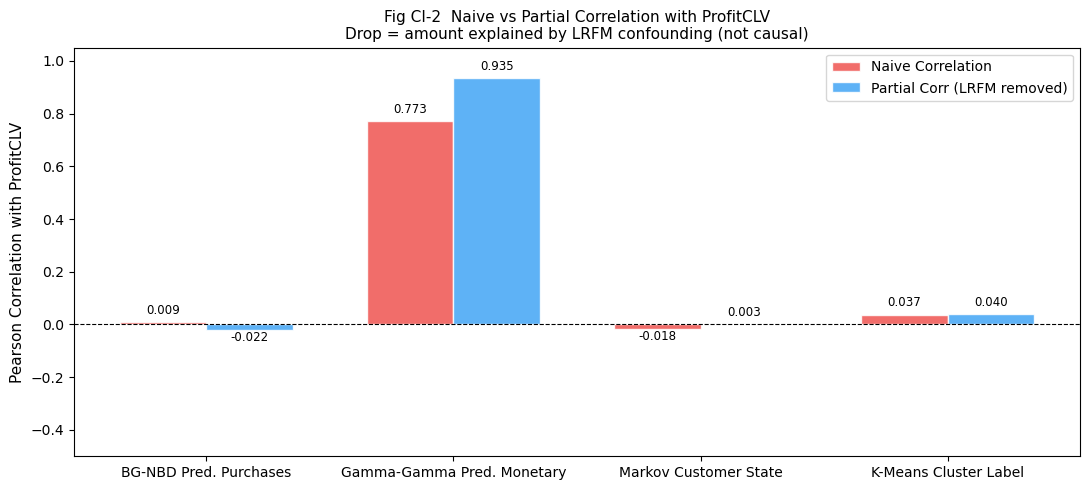

Feature                           Naive   Partial    Drop  Verdict
------------------------------------------------------------------------
BG-NBD Pred. Purchases           0.0090   -0.0224  0.0314  Low confounding
Gamma-Gamma Pred. Monetary       0.7727    0.9354 -0.1628  HIGH confounding
Markov Customer State           -0.0184    0.0025 -0.0209  Low confounding
K-Means Cluster Label            0.0374    0.0401 -0.0027  Low confounding


In [4]:
# =============================================================================
# CELL 2 — Naive vs Partial Correlation
# =============================================================================

# Naive Pearson
naive_corr = [df_model_imp[t].corr(df_model_imp[outcome_col]) for t in treatment_cols]

# Partial correlation (linear LRFM removed)
def partial_corr(t_col, y_col, conf_cols, df):
    lr = LinearRegression()
    lr.fit(df[conf_cols], df[t_col])
    t_r = df[t_col].values - lr.predict(df[conf_cols])
    lr.fit(df[conf_cols], df[y_col])
    y_r = df[y_col].values - lr.predict(df[conf_cols])
    return float(np.corrcoef(t_r, y_r)[0,1])

partial_corrs = [partial_corr(t, outcome_col, confounder_cols, df_model_imp)
                 for t in treatment_cols]

# Plot
x = np.arange(len(treatment_cols)); w = 0.35
fig, ax = plt.subplots(figsize=(11,5))
b1 = ax.bar(x-w/2, naive_corr,    w, label='Naive Correlation',
            color='#EF5350', alpha=0.85, edgecolor='white')
b2 = ax.bar(x+w/2, partial_corrs, w, label='Partial Corr (LRFM removed)',
            color='#42A5F5', alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xticks(x)
ax.set_xticklabels([l.replace('\n',' ') for l in treatment_labels], fontsize=10)
ax.set_ylabel('Pearson Correlation with ProfitCLV', fontsize=11)
ax.set_title('Fig CI-2  Naive vs Partial Correlation with ProfitCLV\n'
             'Drop = amount explained by LRFM confounding (not causal)', fontsize=11)
ax.legend(fontsize=10); ax.set_ylim(-0.5, 1.05)
for bars in [b1, b2]:
    for bar in bars:
        v = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, v+(0.02 if v>=0 else -0.05),
                f'{v:.3f}', ha='center', va='bottom', fontsize=8.5)
plt.tight_layout(); plt.show()

# Summary
print(f"{'Feature':<30} {'Naive':>8} {'Partial':>9} {'Drop':>7}  Verdict")
print("-"*72)
for lb, nc, pc in zip(treatment_short, naive_corr, partial_corrs):
    drop = nc - pc
    note = "HIGH confounding" if abs(drop) > 0.1 else "Low confounding"
    print(f"{lb:<30} {nc:>8.4f} {pc:>9.4f} {drop:>7.4f}  {note}")

# ==========================================================================
# HOW TO INTERPRET:
# Big RED bar → high naive correlation (could be confounded)
# Big BLUE bar → still correlated after removing LRFM (more likely independent signal)
# Drop (Red - Blue) → portion of correlation that was LRFM confounding
# This is LINEAR only. DML (Cell 3) does this non-linearly with Random Forest.
# ==========================================================================

BG-NBD Pred. Purchases            ATE= -37.7111  95%CI=[-199.2590,123.8367]  p=0.6473  n.s.
Gamma-Gamma Pred. Monetary        ATE=   1.6830  95%CI=[1.3445,2.0214]  p=0.0000  ***
Markov Customer State             ATE=-151.2608  95%CI=[-687.6922,385.1705]  p=0.5805  n.s.
K-Means Cluster Label             ATE= 181.9136  95%CI=[-179.7272,543.5545]  p=0.3242  n.s.


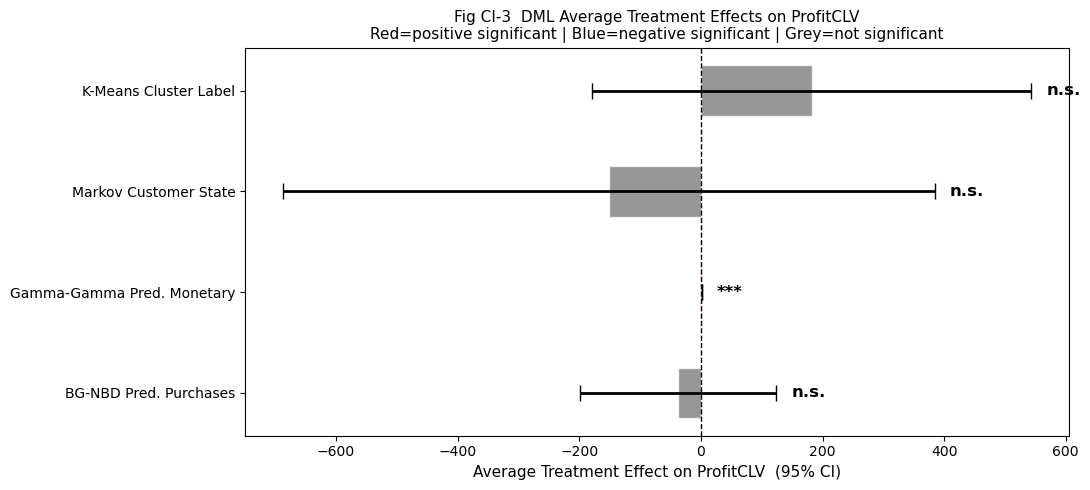


Feature                                 ATE                  95% CI    p-value  Sig
----------------------------------------------------------------------------------
BG-NBD Pred. Purchases             -37.7111  [-199.2590,123.8367]     0.6473  n.s.
Gamma-Gamma Pred. Monetary           1.6830  [  1.3445,  2.0214]     0.0000  ***
Markov Customer State             -151.2608  [-687.6922,385.1705]     0.5805  n.s.
K-Means Cluster Label              181.9136  [-179.7272,543.5545]     0.3242  n.s.

*** p<0.001  ** p<0.01  * p<0.05  n.s.=not significant


In [5]:
# =============================================================================
# CELL 3 — DML Average Treatment Effect (ATE)
# =============================================================================
ate_results = []

for t_col, t_short in zip(treatment_cols, treatment_short):
    T = df_model_imp[[t_col]].values

    est = LinearDML(
        model_y=RandomForestRegressor(n_estimators=300, max_depth=10,
                                      min_samples_leaf=5, random_state=42, n_jobs=-1),
        model_t=RandomForestRegressor(n_estimators=300, max_depth=10,
                                      min_samples_leaf=5, random_state=42, n_jobs=-1),
        linear_first_stages=False,   # use RF, not linear, for first stages
        cv=5,                        # 5-fold cross-fitting to avoid overfitting
        random_state=42
    )
    est.fit(Y, T, X=None, W=W)       # X=None means no effect modifiers at ATE stage

    ate   = float(np.mean(est.effect()))
    ci    = est.effect_interval(alpha=0.05)
    ci_lo = float(np.mean(ci[0]))
    ci_hi = float(np.mean(ci[1]))
    pval  = float(np.mean(est.effect_inference().pvalue()))
    sig   = '***' if pval<0.001 else ('**' if pval<0.01 else ('*' if pval<0.05 else 'n.s.'))

    ate_results.append({'Feature':t_short,'ATE':ate,'CI_lo':ci_lo,
                        'CI_hi':ci_hi,'p_value':pval,'Sig':sig})
    print(f"{t_short:<33} ATE={ate:>9.4f}  95%CI=[{ci_lo:.4f},{ci_hi:.4f}]  p={pval:.4f}  {sig}")

ate_df = pd.DataFrame(ate_results)

# Forest plot
fig, ax = plt.subplots(figsize=(11,5))
col_ate = ['#E53935' if lo>0 else ('#1E88E5' if hi<0 else '#757575')
           for lo,hi in zip(ate_df.CI_lo, ate_df.CI_hi)]
yp = np.arange(len(ate_df))
ax.barh(yp, ate_df.ATE, color=col_ate, alpha=0.75, height=0.5, edgecolor='white')
ax.errorbar(ate_df.ATE, yp,
            xerr=[ate_df.ATE-ate_df.CI_lo, ate_df.CI_hi-ate_df.ATE],
            fmt='none', color='black', capsize=6, lw=2)
ax.axvline(0, color='black', ls='--', lw=1)
ax.set_yticks(yp); ax.set_yticklabels(ate_df.Feature, fontsize=10)
ax.set_xlabel('Average Treatment Effect on ProfitCLV  (95% CI)', fontsize=11)
ax.set_title('Fig CI-3  DML Average Treatment Effects on ProfitCLV\n'
             'Red=positive significant | Blue=negative significant | Grey=not significant',
             fontsize=11)
span = ate_df.CI_hi.max() - ate_df.CI_lo.min()
for i, row in ate_df.iterrows():
    ax.text(row.CI_hi + span*0.02, i, row.Sig, va='center', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print()
print(f"{'Feature':<33} {'ATE':>9}  {'95% CI':>22}  {'p-value':>9}  Sig")
print("-"*82)
for _, r in ate_df.iterrows():
    print(f"{r.Feature:<33} {r.ATE:>9.4f}  [{r.CI_lo:>8.4f},{r.CI_hi:>8.4f}]  "
          f"{r.p_value:>9.4f}  {r.Sig}")
print()
print("*** p<0.001  ** p<0.01  * p<0.05  n.s.=not significant")

# ==========================================================================
# HOW TO INTERPRET:
# ATE > 0, CI fully right of zero, significant:
#   -> Genuine causal driver. A 1-unit increase in this feature CAUSES
#      ATE units of ProfitCLV increase, after removing ALL LRFM confounding.
# ATE ≈ 0 or n.s.:
#   -> Feature predicts ProfitCLV only because both are driven by LRFM.
#      Not an actionable causal lever.
# 95% CI crossing zero = uncertain, do not act on this feature causally.
# Cross-fitting (cv=5) means each fold's out-of-sample residuals are used
#   → avoids overfitting the nuisance models inflating the causal estimate.
# ==========================================================================

BG-NBD Pred. Purchases            mean ITE=   1.815  std=59.833  % positive=51.9%
Gamma-Gamma Pred. Monetary        mean ITE=   1.791  std=1.849  % positive=97.5%
Markov Customer State             mean ITE=-642.662  std=9745.802  % positive=43.4%
K-Means Cluster Label             mean ITE= 284.827  std=1633.435  % positive=52.7%


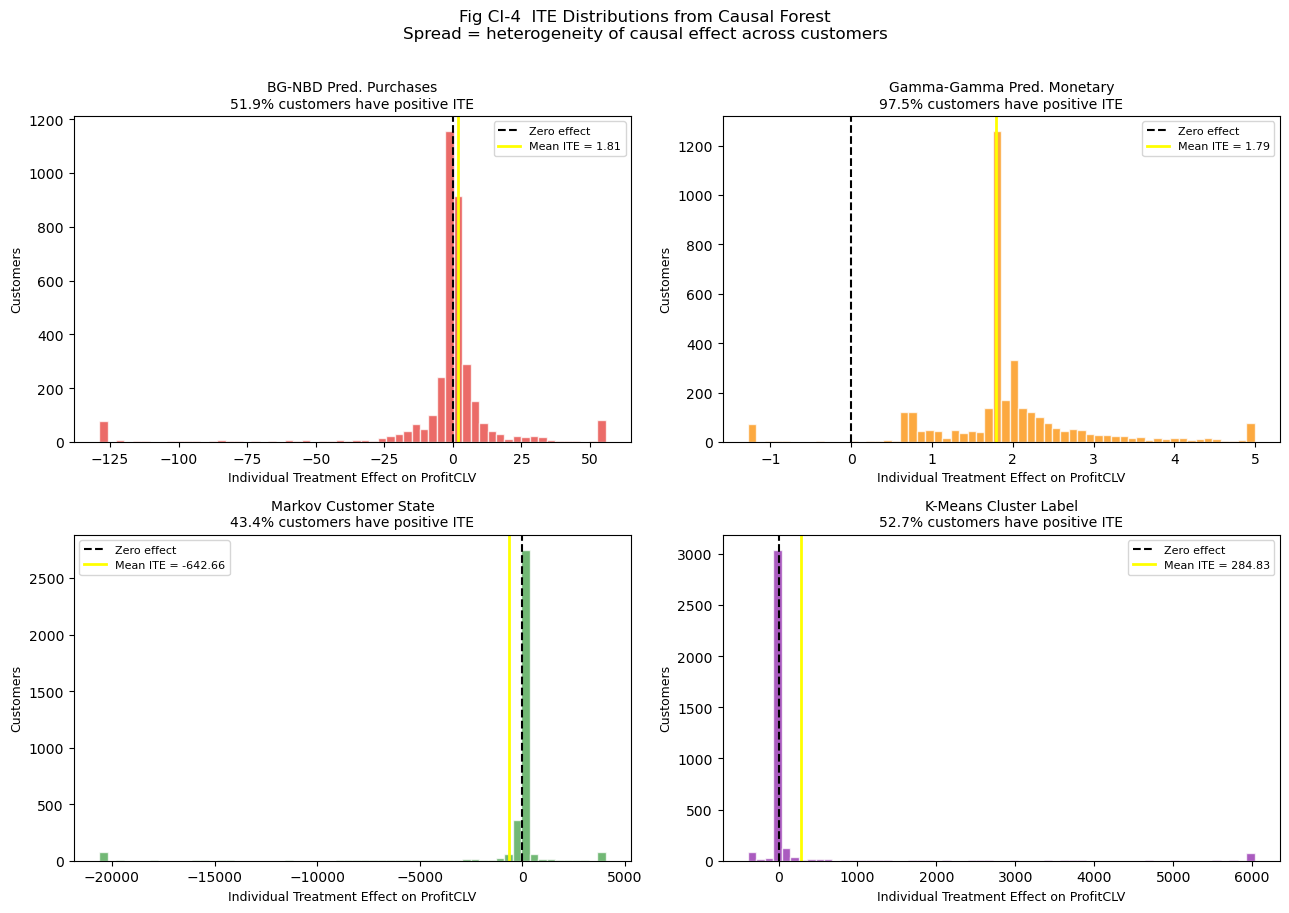

In [6]:
# =============================================================================
# CELL 4 — Causal Forest: Individual Treatment Effects (ITE)
# =============================================================================
X_W      = W.copy()   # LRFM as effect modifiers
ite_dict = {}

for t_col, t_short in zip(treatment_cols, treatment_short):
    T = df_model_imp[[t_col]].values

    cf = CausalForestDML(
        model_y=RandomForestRegressor(n_estimators=200, max_depth=10,
                                      min_samples_leaf=5, random_state=42, n_jobs=-1),
        model_t=RandomForestRegressor(n_estimators=200, max_depth=10,
                                      min_samples_leaf=5, random_state=42, n_jobs=-1),
        n_estimators=300,
        cv=5,
        random_state=42,
        n_jobs=-1
    )
    # X = effect modifiers (LRFM), W=None because already baked into X_W
    cf.fit(Y, T, X=X_W, W=None)
    ite = cf.effect(X_W).flatten()
    ite_dict[t_col] = ite
    df_model_imp[f'ITE_{t_col}'] = ite
    print(f"{t_short:<33} mean ITE={ite.mean():>8.3f}  std={ite.std():.3f}  "
          f"% positive={(ite>0).mean()*100:.1f}%")

# ITE distribution plots
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
palette = ['#E53935','#FB8C00','#43A047','#8E24AA']

for i,(t_col,t_short,color) in enumerate(zip(treatment_cols,treatment_short,palette)):
    ax    = axes[i]
    ites  = ite_dict[t_col]
    m_ite = ites.mean()
    pct_pos = (ites>0).mean()*100
    clip_lo = np.percentile(ites, 2)
    clip_hi = np.percentile(ites, 98)
    ax.hist(np.clip(ites, clip_lo, clip_hi), bins=60,
            color=color, alpha=0.75, edgecolor='white')
    ax.axvline(0,     color='black',  ls='--', lw=1.5, label='Zero effect')
    ax.axvline(m_ite, color='yellow', ls='-',  lw=2.0,
               label=f'Mean ITE = {m_ite:.2f}')
    ax.set_xlabel('Individual Treatment Effect on ProfitCLV', fontsize=9)
    ax.set_ylabel('Customers', fontsize=9)
    ax.set_title(f'{t_short}\n{pct_pos:.1f}% customers have positive ITE', fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle('Fig CI-4  ITE Distributions from Causal Forest\n'
             'Spread = heterogeneity of causal effect across customers',
             fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

# ==========================================================================
# HOW TO INTERPRET:
# Each histogram = distribution of per-customer causal effects for one treatment.
# Wide spread / high std → effect varies a lot by customer → segment-level targeting works.
# Narrow / all near zero → uniform effect or no real effect.
# Yellow line (mean ITE) ≈ ATE from Cell 3 — consistency check.
# % ITE > 0 = share of customers who benefit if this treatment is increased.
# Even if ATE > 0, some customers may have negative ITE — targeting everyone is suboptimal.
# ==========================================================================

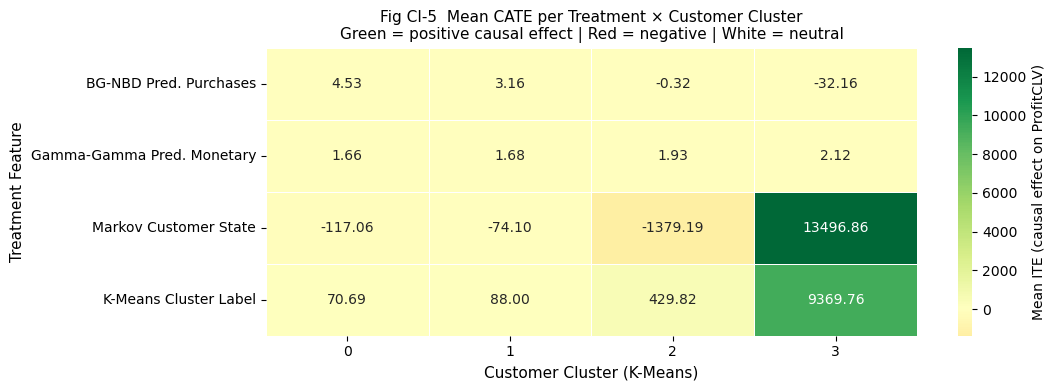

Best treatment (highest ITE) per cluster:
------------------------------------------------------------
  Cluster 0 (n=1185)  ->  K-Means Cluster Label                ITE=70.690
  Cluster 1 (n= 692)  ->  K-Means Cluster Label                ITE=88.001
  Cluster 2 (n=1687)  ->  K-Means Cluster Label                ITE=429.815
  Cluster 3 (n=  16)  ->  Markov Customer State                ITE=13496.861


In [7]:
# =============================================================================
# CELL 5 — CATE by Customer Cluster (K-Means)
# =============================================================================
df_model_imp['Cluster'] = df_model_imp['Cluster_Label'].round().astype(int)
cluster_sizes = df_model_imp['Cluster'].value_counts().sort_index()

ite_cols   = [f'ITE_{t}' for t in treatment_cols]
col_rename = {f'ITE_{t}': s for t,s in zip(treatment_cols, treatment_short)}
hmap = df_model_imp.groupby('Cluster')[ite_cols].mean().rename(columns=col_rename)

# Heatmap
fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(hmap.T, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.6, ax=ax,
            cbar_kws={'label':'Mean ITE (causal effect on ProfitCLV)'})
ax.set_xlabel('Customer Cluster (K-Means)', fontsize=11)
ax.set_ylabel('Treatment Feature', fontsize=11)
ax.set_title('Fig CI-5  Mean CATE per Treatment × Customer Cluster\n'
             'Green = positive causal effect | Red = negative | White = neutral',
             fontsize=11)
plt.tight_layout(); plt.show()

# Best treatment per cluster
print("Best treatment (highest ITE) per cluster:")
print("-"*60)
for cid in sorted(hmap.index):
    best_t = hmap.loc[cid].idxmax()
    best_v = hmap.loc[cid].max()
    n      = cluster_sizes[cid]
    print(f"  Cluster {cid} (n={n:>4})  ->  {best_t:<35}  ITE={best_v:.3f}")

# ==========================================================================
# HOW TO INTERPRET:
# Each cell = expected ProfitCLV change from a 1-unit increase in that treatment
#             for customers in that cluster, with LRFM confounding removed.
# Green cell → THIS is the causal lever to pull for that cluster.
# Red cell   → Increasing this treatment hurts ProfitCLV for this cluster.
# The heatmap directly answers: "Which campaign for which segment?"
# ==========================================================================

BG-NBD Pred. Purchases             Actual=  835.44  Counter=  849.26  Uplift=+1.65%
Gamma-Gamma Pred. Monetary         Actual=  835.44  Counter= 4018.75  Uplift=+381.03%
Markov Customer State              Actual=  835.44  Counter=  613.58  Uplift=-26.56%
K-Means Cluster Label              Actual=  835.44  Counter= 1089.89  Uplift=+30.46%


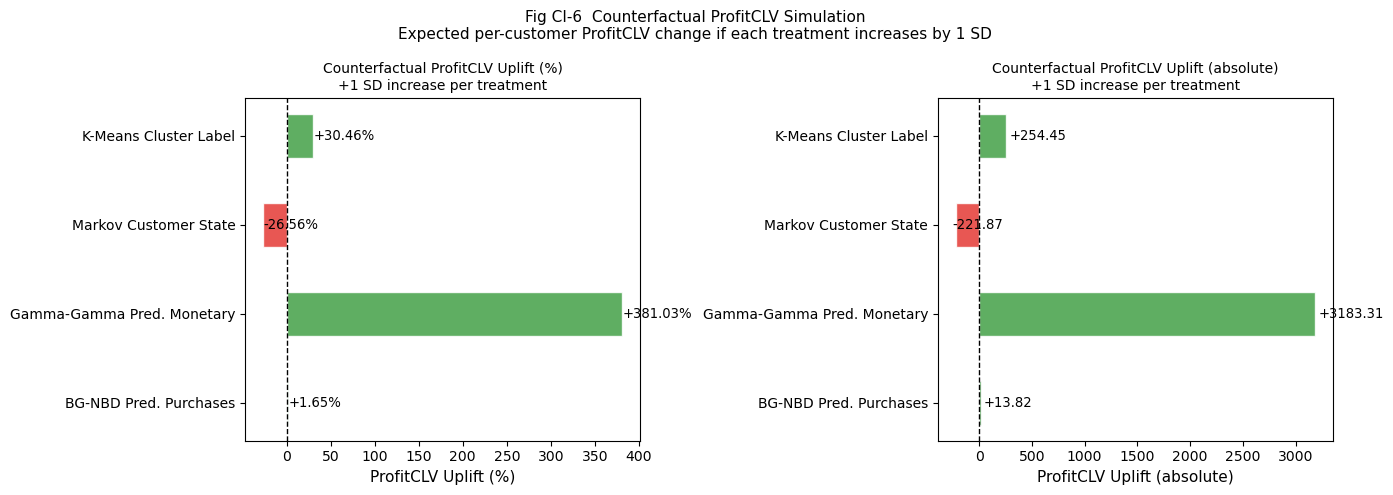


                   Feature  Mean Actual  Mean Counter  Uplift (abs)  Uplift (%)
    BG-NBD Pred. Purchases      835.443       849.259        13.817       1.654
Gamma-Gamma Pred. Monetary      835.443      4018.754      3183.311     381.033
     Markov Customer State      835.443       613.577      -221.866     -26.557
     K-Means Cluster Label      835.443      1089.894       254.452      30.457


In [8]:
# =============================================================================
# CELL 6 — Counterfactual ProfitCLV Simulation
# =============================================================================
actual_clv = Y.copy()
results_cf = []

for t_col, t_short in zip(treatment_cols, treatment_short):
    ite   = ite_dict[t_col]
    t_std = float(df_model_imp[t_col].std())
    cf_y  = actual_clv + ite * t_std        # counterfactual: +1 SD intervention
    m_act = float(actual_clv.mean())
    m_cf  = float(cf_y.mean())
    up_a  = m_cf - m_act
    up_p  = up_a / m_act * 100
    results_cf.append({'Feature':t_short,'Mean Actual':m_act,'Mean Counter':m_cf,
                       'Uplift (abs)':up_a,'Uplift (%)':up_p,'_cf':cf_y})
    print(f"{t_short:<33}  Actual={m_act:>8.2f}  Counter={m_cf:>8.2f}  Uplift={up_p:+.2f}%")

# Uplift bar chart
feats = [r['Feature'] for r in results_cf]
u_pct = [r['Uplift (%)'] for r in results_cf]
u_abs = [r['Uplift (abs)'] for r in results_cf]
c_up  = ['#43A047' if u>0 else '#E53935' for u in u_pct]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(feats, u_pct, color=c_up, alpha=0.85, edgecolor='white', height=0.5)
axes[0].axvline(0, color='black', ls='--', lw=1)
axes[0].set_xlabel('ProfitCLV Uplift (%)', fontsize=11)
axes[0].set_title('Counterfactual ProfitCLV Uplift (%)\n+1 SD increase per treatment', fontsize=10)
for i,v in enumerate(u_pct):
    axes[0].text(v+(0.15 if v>=0 else -0.15), i, f'{v:+.2f}%', va='center', fontsize=9.5)

axes[1].barh(feats, u_abs, color=c_up, alpha=0.85, edgecolor='white', height=0.5)
axes[1].axvline(0, color='black', ls='--', lw=1)
axes[1].set_xlabel('ProfitCLV Uplift (absolute)', fontsize=11)
axes[1].set_title('Counterfactual ProfitCLV Uplift (absolute)\n+1 SD increase per treatment', fontsize=10)
span = max(abs(x) for x in u_abs)
for i,v in enumerate(u_abs):
    axes[1].text(v+span*0.01*(1 if v>=0 else -1), i, f'{v:+.2f}', va='center', fontsize=9.5)

fig.suptitle('Fig CI-6  Counterfactual ProfitCLV Simulation\n'
             'Expected per-customer ProfitCLV change if each treatment increases by 1 SD',
             fontsize=11)
plt.tight_layout(); plt.show()

cf_table = pd.DataFrame([{k:v for k,v in r.items() if not k.startswith('_')}
                          for r in results_cf])
print()
print(cf_table.round(3).to_string(index=False))

# ==========================================================================
# HOW TO INTERPRET:
# Counterfactual = "what would ProfitCLV be if we ran a campaign that
#                  pushed this feature up by 1 standard deviation?"
# Uplift (%) = causal ROI of that campaign, per customer, after LRFM removed.
# This is NOT a prediction. It is a causal estimate of expected uplift.
# Highest uplift % = the feature whose targeted intervention gives best ROI.
# ==========================================================================

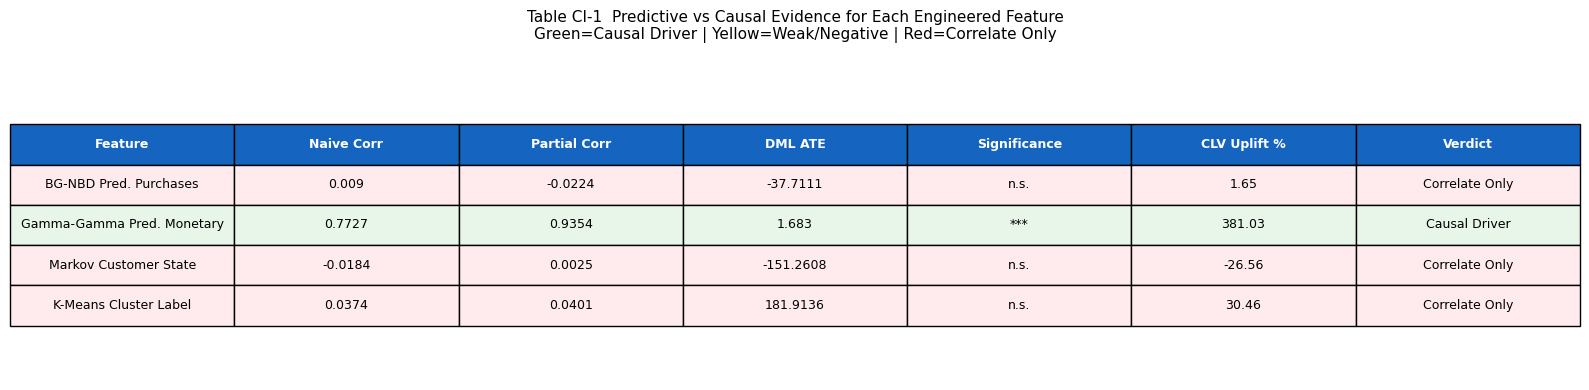

                   Feature  Naive Corr  Partial Corr   DML ATE Significance  CLV Uplift %        Verdict
    BG-NBD Pred. Purchases      0.0090       -0.0224  -37.7111         n.s.          1.65 Correlate Only
Gamma-Gamma Pred. Monetary      0.7727        0.9354    1.6830          ***        381.03  Causal Driver
     Markov Customer State     -0.0184        0.0025 -151.2608         n.s.        -26.56 Correlate Only
     K-Means Cluster Label      0.0374        0.0401  181.9136         n.s.         30.46 Correlate Only

FINAL ANSWER — Which engineered features CAUSALLY drive ProfitCLV?
CAUSAL DRIVERS    : Gamma-Gamma Pred. Monetary
  -> Significant positive ATE. Interventions on these have measurable ROI.
CORRELATES ONLY   : BG-NBD Pred. Purchases, Markov Customer State, K-Means Cluster Label
  -> Useful for prediction models, but not actionable causal levers.


In [10]:
# =============================================================================
# CELL 7 — Final Summary Table: Predictive vs Causal Evidence
# =============================================================================
summary_rows = []
for i,(t_col,t_short) in enumerate(zip(treatment_cols,treatment_short)):
    ate_row = ate_df[ate_df['Feature']==t_short].iloc[0]
    cf_row  = next(r for r in results_cf if r['Feature']==t_short)
    sig     = ate_row['Sig']
    ate_val = float(ate_row['ATE'])
    verdict = ('Causal Driver'
               if sig in ['***','**','*'] and ate_val>0
               else ('Negative/Weak Causal' if sig in ['***','**','*']
                     else 'Correlate Only'))
    summary_rows.append({
        'Feature'      : t_short,
        'Naive Corr'   : round(naive_corr[i],4),
        'Partial Corr' : round(partial_corrs[i],4),
        'DML ATE'      : round(ate_val,4),
        'Significance' : sig,
        'CLV Uplift %' : round(cf_row['Uplift (%)'],2),
        'Verdict'      : verdict
    })

summary_df = pd.DataFrame(summary_rows)

# Styled table
fig, ax = plt.subplots(figsize=(16, 4))
ax.axis('off')
tbl = ax.table(cellText=summary_df.values, colLabels=summary_df.columns,
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 2.4)
for j in range(len(summary_df.columns)):
    tbl[0,j].set_facecolor('#1565C0')
    tbl[0,j].set_text_props(color='white', fontweight='bold')
vcols = {'Causal Driver':'#E8F5E9','Negative/Weak Causal':'#FFF8E1','Correlate Only':'#FFEBEE'}
for i,row in enumerate(summary_df.itertuples(),1):
    c = vcols.get(row.Verdict,'white')
    for j in range(len(summary_df.columns)):
        tbl[i,j].set_facecolor(c)
ax.set_title('Table CI-1  Predictive vs Causal Evidence for Each Engineered Feature\n'
             'Green=Causal Driver | Yellow=Weak/Negative | Red=Correlate Only',
             fontsize=11, pad=22)
plt.tight_layout(); plt.show()

print(summary_df.to_string(index=False))
print()

# Research Question Answer
causal_drivers  = summary_df[summary_df['Verdict']=='Causal Driver']['Feature'].tolist()
correlate_only  = summary_df[summary_df['Verdict']=='Correlate Only']['Feature'].tolist()
negative_causal = summary_df[summary_df['Verdict']=='Negative/Weak Causal']['Feature'].tolist()

print("FINAL ANSWER — Which engineered features CAUSALLY drive ProfitCLV?")
print("="*70)
if causal_drivers:
    print(f"CAUSAL DRIVERS    : {', '.join(causal_drivers)}")
    print("  -> Significant positive ATE. Interventions on these have measurable ROI.")
if negative_causal:
    print(f"NEGATIVE/WEAK     : {', '.join(negative_causal)}")
    print("  -> Do NOT invest campaigns targeting these directly.")
if correlate_only:
    print(f"CORRELATES ONLY   : {', '.join(correlate_only)}")
    print("  -> Useful for prediction models, but not actionable causal levers.")

# ==========================================================================
# READING THE FULL TABLE:
# Naive Corr   = raw association (includes confounding)
# Partial Corr = association after LINEAR LRFM removal
# DML ATE      = causal effect after NON-LINEAR LRFM removal (most credible)
# Significance = statistical certainty of the ATE estimate
# CLV Uplift % = business ROI of a +1 SD campaign on this feature
# Verdict      = actionability classification
#
# The progression Naive → Partial → DML shows how each step of de-confounding
# changes our understanding of each feature's true causal role.
# ==========================================================================